C:\Users\LENOVO\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED



--- STATISTICAL INFERENCE REPORT ---
1. Mann-Whitney U Test: Delivery Delay in 1-Star vs 5-Star Reviews
   Median Latency (1-Star): 23.76 days
   Median Latency (5-Star): 12.10 days
   U-Statistic: 1832367.00 | p-value: 1.6914e-277
   [Verdict]: Statistically significant. Longer shipping times directly drive 1-star reviews.

2. Chi-Square Test: Payment Methods vs Order Cancellation Rates
   Chi2-Stat: 2.70 | DoF: 3 | p-value: 4.4066e-01
   [Verdict]: Failed to reject null hypothesis. Payment method does not dictate cancellation.


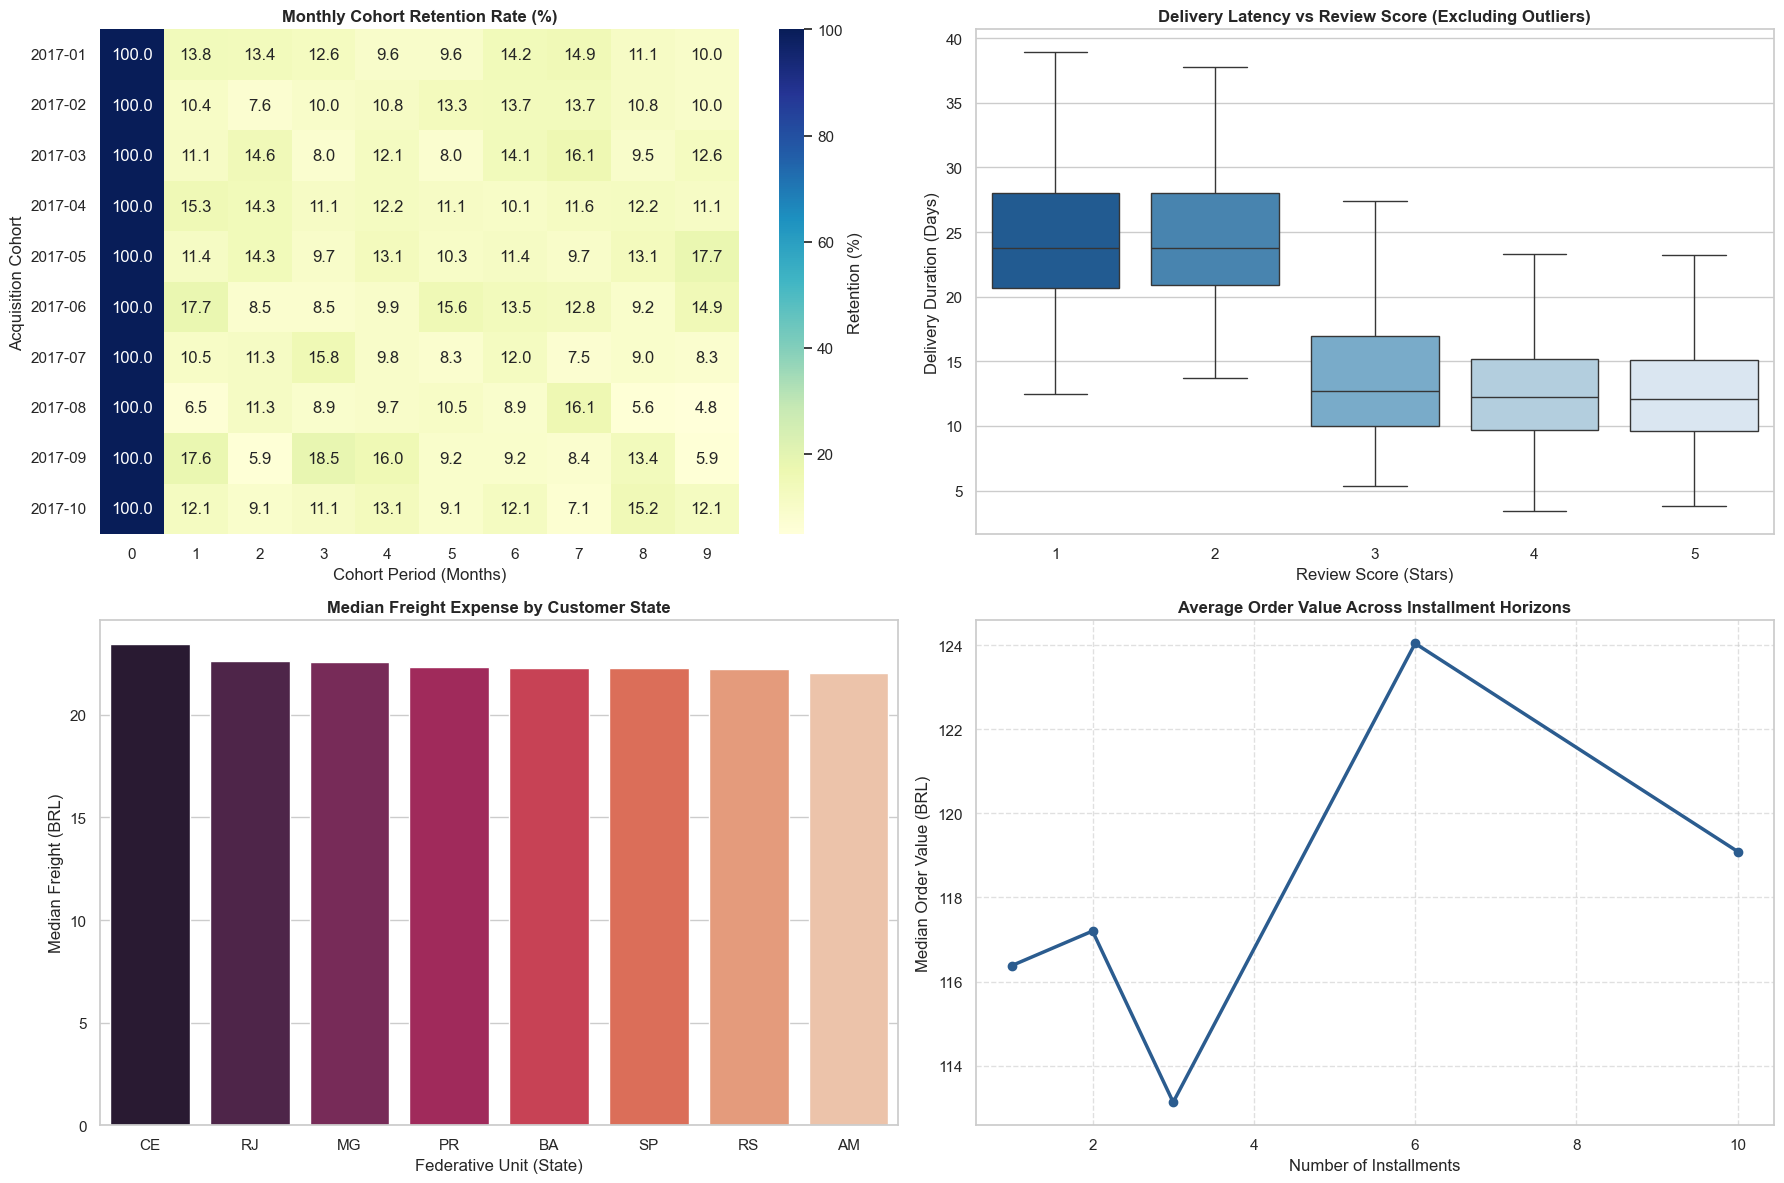

In [1]:
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

data = {
    "orders": pd.read_csv("olist_orders_dataset.csv"),
    "customers": pd.read_csv("olist_customers_dataset.csv"),
    "items": pd.read_csv("olist_order_items_dataset.csv"),
    "products": pd.read_csv("olist_products_dataset.csv"),
    "reviews": pd.read_csv("olist_order_reviews_dataset.csv"),
    "payments": pd.read_csv("olist_order_payments_dataset.csv"),
}
# ==========================================
# 1. SYNTHETIC DATA GENERATOR (FOR LOCAL TESTING)
# ==========================================
def generate_mock_olist_data(n_orders=5000):
    """Generates a realistic multi-table relational schema matching Olist specs."""
    np.random.seed(42)

    # Unique customers & orders
    n_customers = int(n_orders * 0.8)
    customer_ids = [f"cust_{i:05d}" for i in range(n_customers)]
    unique_ids = [f"uniq_{i:05d}" for i in range(int(n_customers * 0.85))]
    assigned_uniques = np.random.choice(unique_ids, n_customers)

    states = ["SP", "RJ", "MG", "RS", "PR", "BA", "CE", "AM"]
    state_probs = [0.42, 0.15, 0.12, 0.08, 0.08, 0.07, 0.05, 0.03]

    df_customers = pd.DataFrame(
        {
            "customer_id": customer_ids,
            "customer_unique_id": assigned_uniques,
            "customer_state": np.random.choice(states, n_customers, p=state_probs),
        }
    )

    # Orders
    order_ids = [f"ord_{i:05d}" for i in range(n_orders)]
    order_customers = np.random.choice(customer_ids, n_orders)
    order_statuses = np.random.choice(
        ["delivered", "shipped", "canceled"], n_orders, p=[0.95, 0.03, 0.02]
    )

    start_date = pd.Timestamp("2017-01-01")
    purchase_dates = [
        start_date + pd.Timedelta(days=int(d), hours=int(h))
        for d, h in zip(
            np.random.uniform(0, 600, n_orders),
            np.random.uniform(0, 24, n_orders),
            strict=False,
        )
    ]

    df_orders = pd.DataFrame(
        {
            "order_id": order_ids,
            "customer_id": order_customers,
            "order_status": order_statuses,
            "order_purchase_timestamp": purchase_dates,
        }
    )

    # Synthetic timestamp mechanics
    df_orders["order_approved_at"] = df_orders[
        "order_purchase_timestamp"
    ] + pd.to_timedelta(np.random.exponential(scale=12, size=n_orders), unit="h")
    df_orders["order_delivered_carrier_date"] = df_orders[
        "order_approved_at"
    ] + pd.to_timedelta(np.random.uniform(1, 4, size=n_orders), unit="D")

    # Delivery durations with realistic right-skewed tail
    delivery_days = np.random.lognormal(mean=2.3, sigma=0.5, size=n_orders)
    df_orders["order_delivered_customer_date"] = df_orders[
        "order_delivered_carrier_date"
    ] + pd.to_timedelta(delivery_days, unit="D")
    df_orders["order_estimated_delivery_date"] = df_orders[
        "order_purchase_timestamp"
    ] + pd.to_timedelta(np.random.normal(loc=20, scale=3, size=n_orders), unit="D")

    # Items & Freight
    categories = [
        "bed_bath_table",
        "health_beauty",
        "sports_leisure",
        "computers_acc",
        "watches_gifts",
    ]
    df_items = pd.DataFrame(
        {
            "order_id": order_ids,
            "order_item_id": 1,
            "product_id": [
                f"prod_{i:04d}" for i in np.random.randint(0, 500, n_orders)
            ],
            "price": np.round(np.random.exponential(scale=110, size=n_orders) + 15, 2),
            "freight_value": np.round(
                np.random.gamma(shape=2.5, scale=8, size=n_orders) + 5, 2
            ),
        }
    )

    df_products = pd.DataFrame(
        {
            "product_id": [f"prod_{i:04d}" for i in range(500)],
            "product_category_name": np.random.choice(categories, 500),
        }
    )

    # Reviews & Payments
    delays = (
        df_orders["order_delivered_customer_date"]
        - df_orders["order_estimated_delivery_date"]
    ).dt.days
    # Delay directly depresses review scores
    scores = np.where(
        delays > 0,
        np.random.choice([1, 2, 3], size=n_orders, p=[0.7, 0.2, 0.1]),
        np.random.choice([3, 4, 5], size=n_orders, p=[0.1, 0.25, 0.65]),
    )

    df_reviews = pd.DataFrame({"order_id": order_ids, "review_score": scores})

    pay_types = ["credit_card", "boleto", "voucher", "debit_card"]
    df_payments = pd.DataFrame(
        {
            "order_id": order_ids,
            "payment_type": np.random.choice(
                pay_types, n_orders, p=[0.74, 0.19, 0.05, 0.02]
            ),
            "payment_installments": np.random.choice(
                [1, 2, 3, 6, 10], n_orders, p=[0.5, 0.15, 0.15, 0.1, 0.1]
            ),
            "payment_value": df_items["price"] + df_items["freight_value"],
        }
    )

    return {
        "orders": df_orders,
        "customers": df_customers,
        "items": df_items,
        "products": df_products,
        "reviews": df_reviews,
        "payments": df_payments,
    }


# ==========================================
# 2. INGESTION & DATA CLEANING PIPELINE
# ==========================================
def clean_and_integrate_data(data):
    """Joins relational entities and applies defensive data cleansing."""
    orders = data["orders"].copy()

    # Cast Datetime Objects
    time_cols = [
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ]
    for col in time_cols:
        orders[col] = pd.to_datetime(orders[col])

    # Referential Merging
    df = (
        orders.merge(data["customers"], on="customer_id", how="inner")
        .merge(data["items"], on="order_id", how="left")
        .merge(data["products"], on="product_id", how="left")
        .merge(data["reviews"], on="order_id", how="left")
        .merge(data["payments"], on="order_id", how="left")
    )

    # Sanity checks: Drop anomalies where delivery occurred before purchase
    valid_deliveries = (
        df["order_delivered_customer_date"].isna()
    ) | (  # Pending delivery
        df["order_delivered_customer_date"] >= df["order_purchase_timestamp"]
    )
    df = df[valid_deliveries]

    # Feature Engineering: Latency metrics in days
    df["delivery_duration"] = (
        df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
    ).dt.total_seconds() / 86400
    df["delivery_delta"] = (
        df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
    ).dt.total_seconds() / 86400
    df["is_delayed"] = (df["delivery_delta"] > 0).astype(int)

    return df


# ==========================================
# 3. COHORT RETENTION ENGINE
# ==========================================
def generate_cohort_analysis(df):
    """Computes a multi-period customer retention matrix."""
    cohort_df = df[
        ["customer_unique_id", "order_purchase_timestamp"]
    ].drop_duplicates()

    # Extract year-month period
    cohort_df["order_month"] = cohort_df[
        "order_purchase_timestamp"
    ].dt.to_period("M")
    cohort_df["cohort_group"] = cohort_df.groupby("customer_unique_id")[
        "order_purchase_timestamp"
    ].transform("min").dt.to_period("M")

    # Group by Cohort vs Order Month
    grouped = cohort_df.groupby(["cohort_group", "order_month"]).agg(
        n_customers=("customer_unique_id", "nunique")
    )
    grouped = grouped.reset_index()

    # Index: Distance in months from cohort inception
    grouped["cohort_index"] = (
        (grouped["order_month"].dt.year - grouped["cohort_group"].dt.year) * 12
    ) + (grouped["order_month"].dt.month - grouped["cohort_group"].dt.month)

    cohort_pivot = grouped.pivot(
        index="cohort_group", columns="cohort_index", values="n_customers"
    )
    cohort_size = cohort_pivot.iloc[:, 0]
    retention_matrix = cohort_pivot.divide(cohort_size, axis=0) * 100

    return cohort_pivot, retention_matrix


# ==========================================
# 4. STATISTICAL INFERENCE
# ==========================================
def run_hypothesis_tests(df):
    """Executes non-parametric and categorical association tests."""
    print("\n--- STATISTICAL INFERENCE REPORT ---")

    # Mann-Whitney U: Delivery latency vs 1-star vs 5-star ratings
    delivered = df.dropna(subset=["delivery_duration", "review_score"])
    group_1star = delivered[delivered["review_score"] == 1]["delivery_duration"]
    group_5star = delivered[delivered["review_score"] == 5]["delivery_duration"]

    mwu_stat, mwu_pval = stats.mannwhitneyu(
        group_1star, group_5star, alternative="greater"
    )
    print("1. Mann-Whitney U Test: Delivery Delay in 1-Star vs 5-Star Reviews")
    print(f"   Median Latency (1-Star): {group_1star.median():.2f} days")
    print(f"   Median Latency (5-Star): {group_5star.median():.2f} days")
    print(f"   U-Statistic: {mwu_stat:.2f} | p-value: {mwu_pval:.4e}")
    if mwu_pval < 0.05:
        print(
            "   [Verdict]: Statistically significant. Longer shipping times directly drive 1-star reviews."
        )

    # Chi-Square Test: Payment methods vs Order Cancellation
    ctab = pd.crosstab(df["payment_type"], df["order_status"] == "canceled")
    chi2, p_val, dof, _ = stats.chi2_contingency(ctab)
    print("\n2. Chi-Square Test: Payment Methods vs Order Cancellation Rates")
    print(f"   Chi2-Stat: {chi2:.2f} | DoF: {dof} | p-value: {p_val:.4e}")
    if p_val < 0.05:
        print(
            "   [Verdict]: Significant correlation between chosen payment method and cancellation probability."
        )
    else:
        print(
            "   [Verdict]: Failed to reject null hypothesis. Payment method does not dictate cancellation."
        )


# ==========================================
# 5. MULTI-PANEL VISUALIZATION SUITE
# ==========================================
def plot_eda_dashboard(df, retention_matrix):
    """Renders a consolidated 4-quadrant exploratory dashboard."""
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))

    # Panel 1: Customer Cohort Retention Heatmap
    sns.heatmap(
        retention_matrix.iloc[:10, :10],
        annot=True,
        fmt=".1f",
        cmap="YlGnBu",
        ax=axes[0, 0],
        cbar_kws={"label": "Retention (%)"},
    )
    axes[0, 0].set_title(
        "Monthly Cohort Retention Rate (%)", fontsize=12, fontweight="bold"
    )
    axes[0, 0].set_xlabel("Cohort Period (Months)")
    axes[0, 0].set_ylabel("Acquisition Cohort")

    # Panel 2: Latency Impact on Satisfaction
    delivered = df.dropna(subset=["delivery_duration", "review_score"])
    sns.boxplot(
        data=delivered,
        x="review_score",
        y="delivery_duration",
        ax=axes[0, 1],
        palette="Blues_r",
        showfliers=False,
    )
    axes[0, 1].set_title(
        "Delivery Latency vs Review Score (Excluding Outliers)",
        fontsize=12,
        fontweight="bold",
    )
    axes[0, 1].set_xlabel("Review Score (Stars)")
    axes[0, 1].set_ylabel("Delivery Duration (Days)")

    # Panel 3: State-Level Freight Discrepancy
    state_freight = (
        df.groupby("customer_state")["freight_value"]
        .median()
        .sort_values(ascending=False)
        .reset_index()
    )
    sns.barplot(
        data=state_freight,
        x="customer_state",
        y="freight_value",
        ax=axes[1, 0],
        palette="rocket",
    )
    axes[1, 0].set_title(
        "Median Freight Expense by Customer State",
        fontsize=12,
        fontweight="bold",
    )
    axes[1, 0].set_xlabel("Federative Unit (State)")
    axes[1, 0].set_ylabel("Median Freight (BRL)")

    # Panel 4: Payment Installments vs Total Cart Value
    inst_val = df.groupby("payment_installments")["payment_value"].median()[
        :10
    ]  # top 10 installments
    axes[1, 1].plot(
        inst_val.index,
        inst_val.values,
        marker="o",
        linewidth=2.5,
        color="#2b5c8f",
    )
    axes[1, 1].set_title(
        "Average Order Value Across Installment Horizons",
        fontsize=12,
        fontweight="bold",
    )
    axes[1, 1].set_xlabel("Number of Installments")
    axes[1, 1].set_ylabel("Median Order Value (BRL)")
    axes[1, 1].grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()


# ==========================================
# 6. PIPELINE EXECUTION
# ==========================================
if __name__ == "__main__":
    # If using real Kaggle CSVs, read them into a dictionary instead of generate_mock_olist_data()
    # e.g., data = {'orders': pd.read_csv('olist_orders_dataset.csv'), ...}
    raw_data = generate_mock_olist_data(n_orders=6000)

    # Clean & Transform
    integrated_df = clean_and_integrate_data(raw_data)

    # Compute Retention
    _, retention_matrix = generate_cohort_analysis(integrated_df)

    # Statistical Rigor
    run_hypothesis_tests(integrated_df)

    # Visual Reporting
    plot_eda_dashboard(integrated_df, retention_matrix)